In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [2]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

##### As Per The EDA Droping Fertures that has with One to One correlation with Target ["diagnosed_diabetes"]

In [4]:
#Remove any Higly correlated features as per EDA analysis
data = data.drop(columns=['diabetes_stage','diabetes_risk_score'])

#### Spliit Data to  train on one part and test on unseen data.

In [5]:
# Spliit Data to  train on one part and test on unseen data.
X = data.drop('diagnosed_diabetes', axis=1)
y = data['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Try to Exacute Decion Tree with out Encoding data since Trees Algorithms Trees split data based on thresholds so they do not assume numeric order.}

In [9]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

ValueError: could not convert string to float: 'Female'

Evan though Tree algorthms like [Decision Tree / Random Forest] not needed to encode catagorical fertures to numarical since using scikit-learn we  must still need to  convert categorical text into  numbers

#### One Hot Encode Data

In [6]:
## One Hot Encode Data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

##### Decision Tree Clasifier

In [17]:
## Decision Tree Classifier with Encoded Data
dt_classifier_encoded = DecisionTreeClassifier(random_state=42)
dt_classifier_encoded.fit(X_train_encoded, y_train)
y_pred_dt_encoded = dt_classifier_encoded.predict(X_test_encoded)
print("Decision Tree Classifier with Encoded Data Accuracy:", accuracy_score(y_test, y_pred_dt_encoded))
print(classification_report(y_test, y_pred_dt_encoded))

Decision Tree Classifier with Encoded Data Accuracy: 0.85995
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      8000
           1       0.88      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6493  1507]
 [ 1294 10706]]


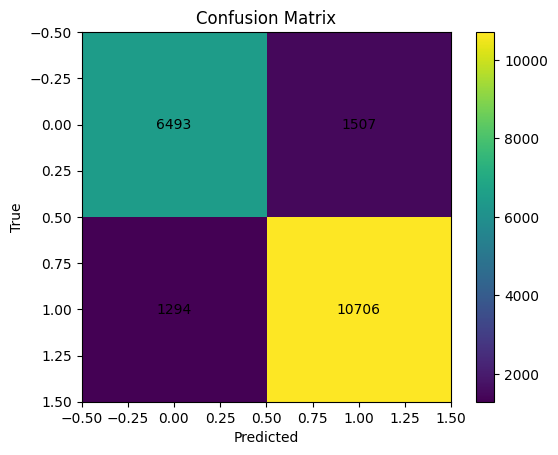

In [ ]:
# Decision Tree Confusion Metrics
cm = confusion_matrix(y_test,y_pred_dt_encoded)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

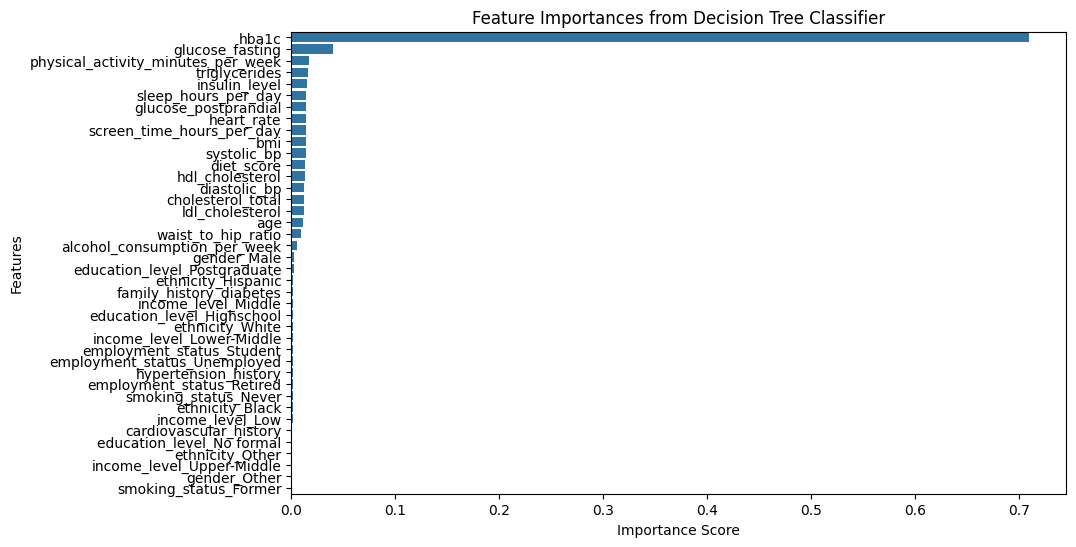

In [13]:
# Decision Tree Ferture Importance
feature_importances = pd.Series(dt_classifier_encoded.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Random Forest Classifier

In [16]:
## Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_encoded, y_train)
y_pred_rf = rf_classifier.predict(X_test_encoded)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.91965
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 7995     5]
 [ 1602 10398]]


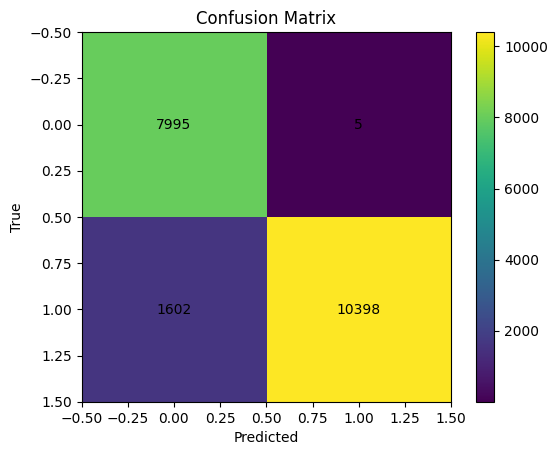

In [21]:
# Random Forest Confusion Metrics
cm = confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

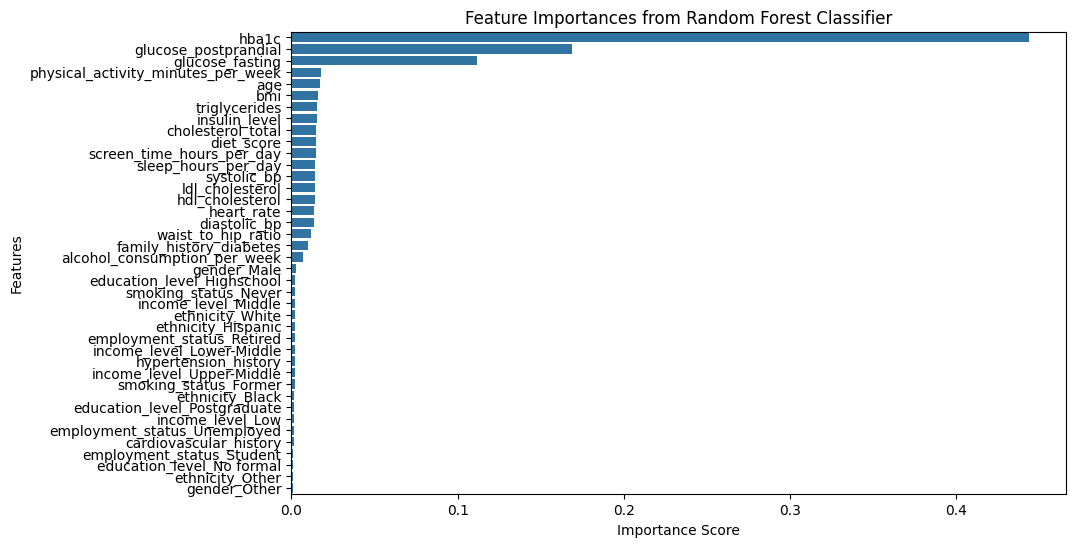

In [34]:
# random forest feature importance
rf_feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_encoded.columns)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feature_importances, y=rf_feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Gradian Boosting Classifier?

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

All features are now on the same scale (mean=0, std=1), so no feature dominates because of large numbers. This step is importan for modules like Logistic Regression & Gradian Boosting /XGBoost  wich that rely on distance/gradients perform better.

In [26]:
# Gradian Boosting Clasifier 
# Initialize the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,   # Number of boosting stages
    learning_rate=0.1,  # Step size shrinkage
    max_depth=3,        # Maximum depth of individual estimators
    random_state=42
)

# Fit the model
gb_clf.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_gb = gb_clf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_gb)
print("Accuracy:", accuracy)
# Get predicted probabilities for the positive class
y_prob_gb = gb_clf.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_prob_gb)
print("ROC AUC Score:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.9199
ROC AUC Score: 0.944390015625

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 8000     0]
 [ 1602 10398]]


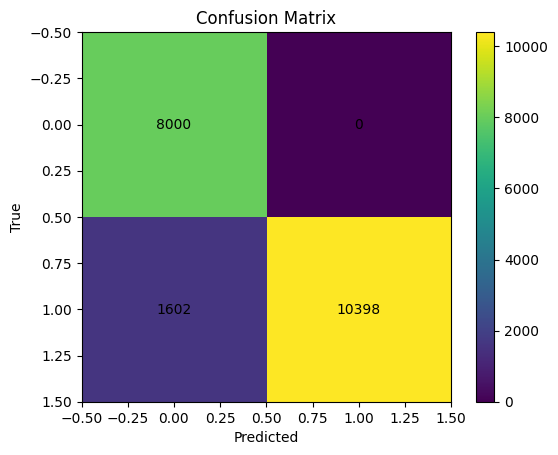

In [12]:
# Gradiant Confusion Metrics
cm = confusion_matrix(y_test,y_pred_gb)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

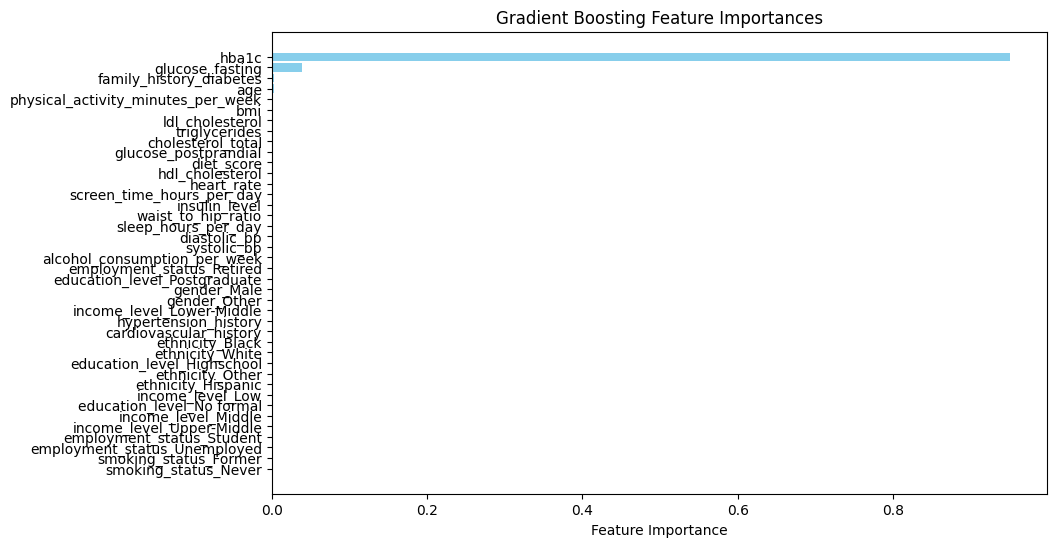

In [30]:
# Get feature importances from the model
feature_importances_gb = gb_clf.feature_importances_

# Map feature importances to feature names
features = X_train_encoded.columns
importance_df_gb = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances_gb
})

# Sort features by importance
importance_df_gb = importance_df_gb.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df_gb['Feature'], importance_df_gb['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importances')
plt.show()

In [37]:
importance_df_gb.columns

Index(['Feature', 'Importance'], dtype='object')

#### Logistic Regression Classifier 

In [15]:
## Logistic Regression Classifier
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_classifier.predict(X_test_scaled)
print("Logistic Regression Classifier Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Classifier Accuracy: 0.86085
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.90      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6475  1525]
 [ 1258 10742]]


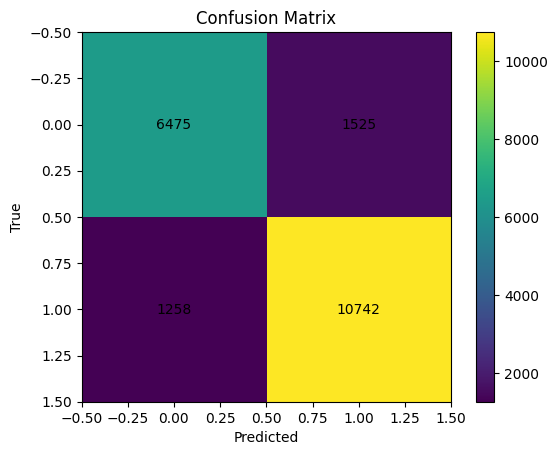

In [26]:
# Logistic Regression Confusion Metrics
cm = confusion_matrix(y_test,y_pred_logreg)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

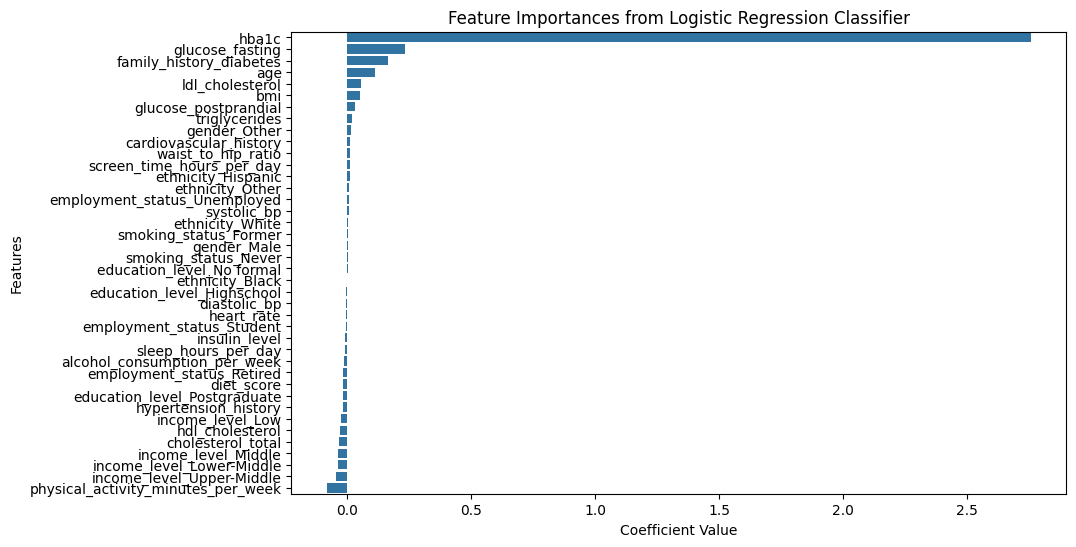

In [33]:
## logistic regression feature importance
logreg_feature_importances = pd.Series(logreg_classifier.coef_[0], index=X_train_encoded.columns)
logreg_feature_importances = logreg_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=logreg_feature_importances, y=logreg_feature_importances.index)
plt.title('Feature Importances from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

#### XGBoost using For high Accuracy 

In [1]:
!pip install xgboost

  Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.28.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl (115.9 MB)
Using cached nvidia_nccl_cu12-2.28.7-py3-none-manylinux_2_18_x86_64.whl (296.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [19]:
import xgboost as xgb
from xgboost import XGBClassifier


In [20]:
xgb_model = XGBClassifier(
    objective='binary:logistic',   # binary classification
    eval_metric='logloss',         # required to avoid warnings
    n_estimators=300,              # number of trees
    learning_rate=0.05,            # shrinkage
    max_depth=5,                   # depth of trees
    subsample=0.8,                 # row sampling
    colsample_bytree=0.8,          # feature sampling
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1] 

In [21]:
# XGBoost Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.91985
Precision: 0.9999038369073949
Recall: 0.8665
F1 Score: 0.9284343051029064
ROC AUC: 0.9435177604166666

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 7999     1]
 [ 1602 10398]]


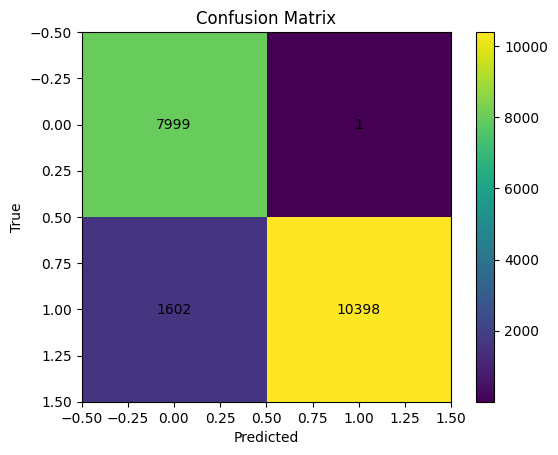

In [16]:
# Confussion metrics
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

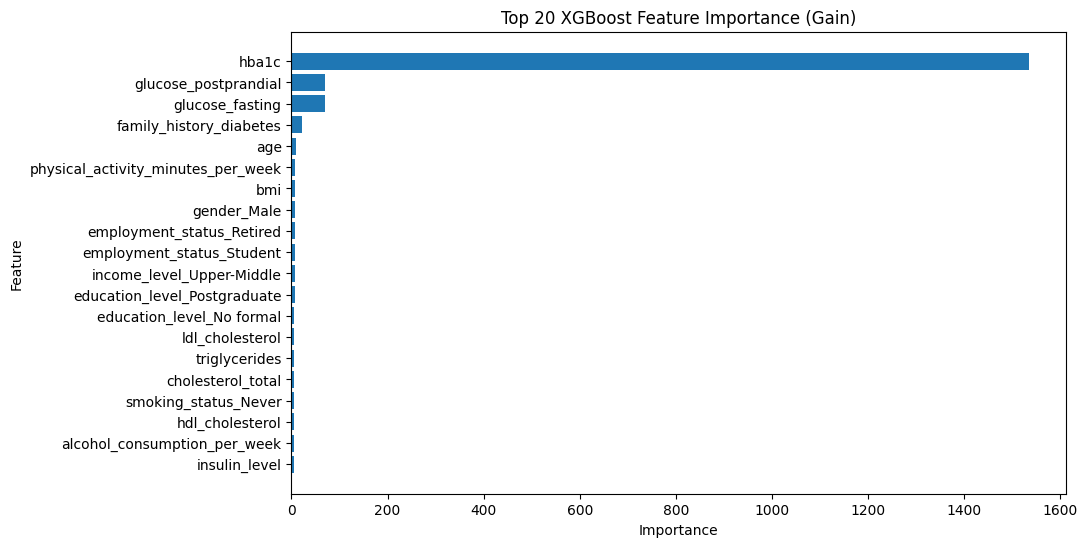

In [32]:
# XGBoost Ferture Importance 
# Get actual feature names
feature_names = X_train_encoded.columns

# Get raw importance dictionary from XGBoost
score_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Convert XGBoost f0/f1/f2... into real feature names
mapped_scores = {
    feature_names[int(k[1:])]: v   # remove "f" and convert index -> real column name
    for k, v in score_dict.items()
}

# Create DataFrame
df_imp = pd.DataFrame({
    "feature": list(mapped_scores.keys()),
    "importance": list(mapped_scores.values())
})

# Sort & get top 20
df_imp = df_imp.sort_values(by="importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.title("Top 20 XGBoost Feature Importance (Gain)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Final Model Selection For The Given Data

In [25]:
# Model Comparison
models = {
    'Decision Tree': accuracy_score(y_test, y_pred_dt_encoded),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'GradientBoost':accuracy_score(y_test, y_pred_gb),
    'Logistic Regression': accuracy_score(y_test, y_pred_logreg),
    'XgBoost':accuracy_score(y_test, y_pred)
    
}
print("Model Comparison (Accuracy Scores):")
for model, accuracy in models.items():
    print(f"{model}: {accuracy:.4f}")

Model Comparison (Accuracy Scores):
Decision Tree: 0.8599
Random Forest: 0.9196
GradientBoost: 0.9199
Logistic Regression: 0.8609
XgBoost: 0.9198


In [24]:
# Model Comparison Usinfg F1 Score
from sklearn.metrics import f1_score
f1_scores = {
    'Decision Tree': f1_score(y_test, y_pred_dt_encoded),
    'Random Forest': f1_score(y_test, y_pred_rf),
    'GradientBoost':f1_score(y_test, y_pred_gb),
    'Logistic Regression': f1_score(y_test, y_pred_logreg),
    'XgBoost':f1_score(y_test, y_pred)
}
print("\nModel Comparison (F1 Scores):")
for model, f1 in f1_scores.items():
    print(f"{model}: {f1:.4f}")


Model Comparison (F1 Scores):
Decision Tree: 0.8843
Random Forest: 0.9283
GradientBoost: 0.9285
Logistic Regression: 0.8853
XgBoost: 0.9284


In [29]:
# Model Comparison Using ROC AUC Score
roc_auc_scores = {
    'Decision Tree': roc_auc_score(y_test, dt_classifier_encoded.predict_proba(X_test_encoded)[:,1]),
    'Random Forest': roc_auc_score(y_test, rf_classifier.predict_proba(X_test_encoded)[:,1]),
    'GradientBoost': roc_auc_score(y_test, gb_clf.predict_proba(X_test_scaled)[:, 1]),
    'Logistic Regression': roc_auc_score(y_test, logreg_classifier.predict_proba(X_test_scaled)[:,1]),
    'XgBoost':roc_auc_score(y_test, y_proba)
}
print("\nModel Comparison (ROC AUC Scores):")
for model, roc_auc in roc_auc_scores.items():
    print(f"{model}: {roc_auc:.4f}")


Model Comparison (ROC AUC Scores):
Decision Tree: 0.8519
Random Forest: 0.9412
GradientBoost: 0.9444
Logistic Regression: 0.9337
XgBoost: 0.9435


In [38]:
# Convert XGBoost importance DataFrame to Series if needed
xg_top = df_imp.set_index('feature')['importance']

# Convert Gradient Boosting importance to Series if needed
gb_top = pd.Series(gb_clf.feature_importances_, index=X_train_encoded.columns)

# Take top 10 from each
top_n = 10
lr_top = logreg_feature_importances.sort_values(ascending=False).head(top_n)
rf_top = rf_feature_importances.sort_values(ascending=False).head(top_n)
xg_top = xg_top.sort_values(ascending=False).head(top_n)
gb_top = gb_top.sort_values(ascending=False).head(top_n)

# Get union of all feature names
all_features = set(lr_top.index) | set(rf_top.index) | set(xg_top.index) | set(gb_top.index)

# Reindex each Series to have the same index (fill missing with 0)
lr_top = lr_top.reindex(all_features, fill_value=0)
rf_top = rf_top.reindex(all_features, fill_value=0)
xg_top = xg_top.reindex(all_features, fill_value=0)
gb_top = gb_top.reindex(all_features, fill_value=0)

# Combine into a DataFrame
importance_df = pd.DataFrame({
    "Logistic_Regression": lr_top,
    "Random_Forest": rf_top,
    "XGBoost": xg_top,
    "GradientBoost": gb_top
})

importance_df

,Logistic_Regression,Random_Forest,XGBoost,GradientBoost
glucose_fasting,0.231742,0.111880,69.848434,0.039454
bmi,0.050292,0.016067,6.909252,0.000811
employment_status_Retired,0.000000,0.000000,6.799673,0.000000
glucose_postprandial,0.031210,0.168993,70.164162,0.000227
cholesterol_total,0.000000,0.014931,0.000000,0.000251
hba1c,2.757638,0.444040,1535.964844,0.950481
gender_Other,0.016138,0.000000,0.000000,0.000000
ldl_cholesterol,0.054739,0.000000,0.000000,0.000285
age,0.112899,0.017084,10.264549,0.002777
family_history_diabetes,0.163595,0.000000,21.796095,0.002917


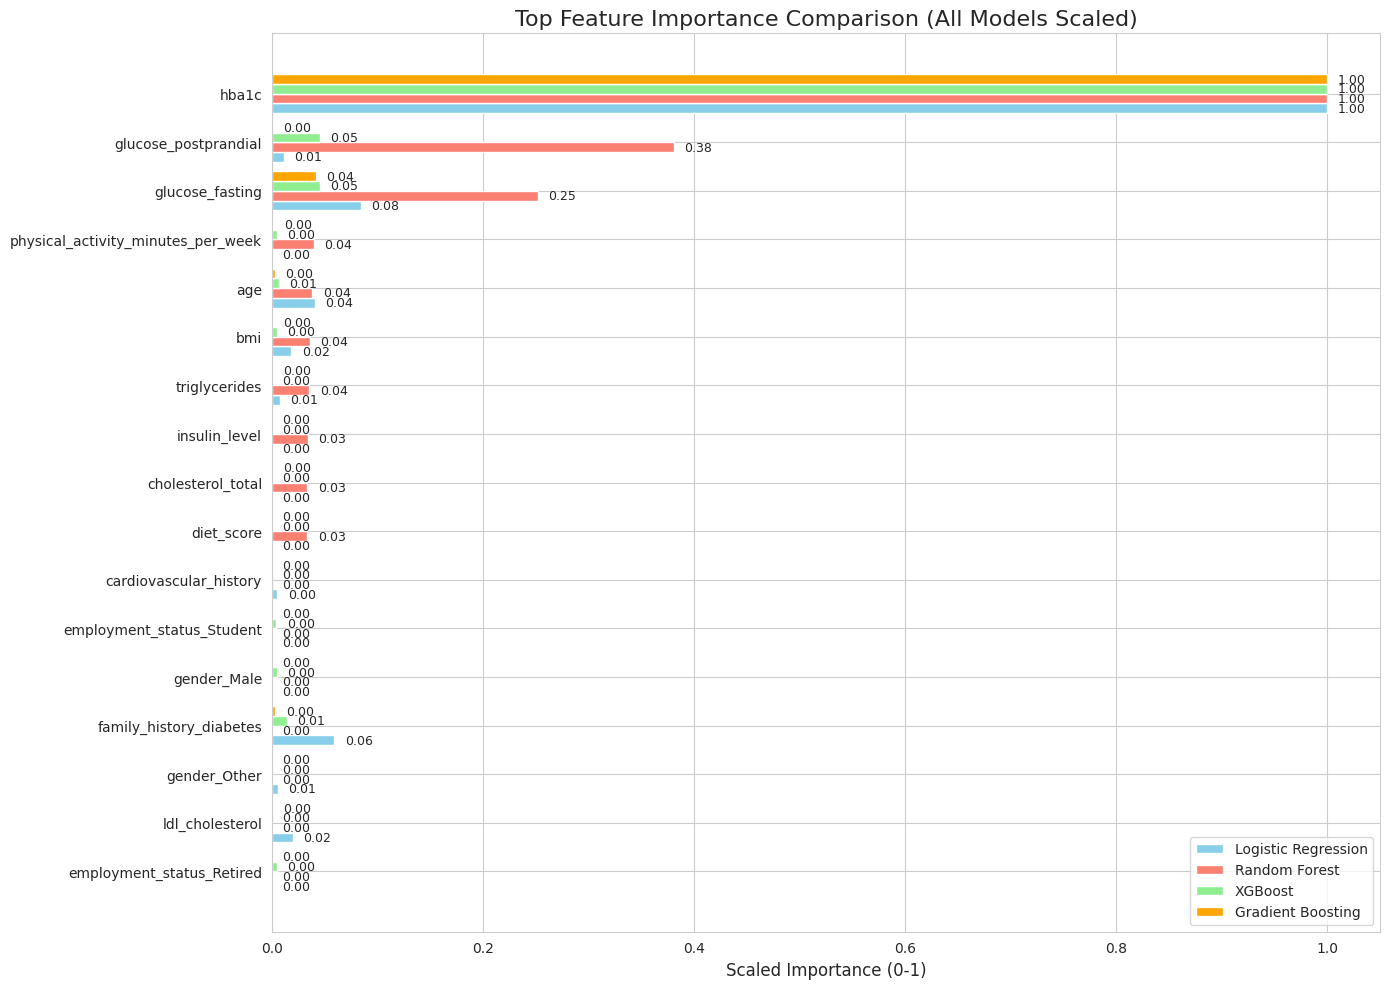

In [40]:
# Scale each model's importance to [0,1] for comparability
importance_df_scaled = importance_df.copy()
importance_df_scaled["Logistic_Regression"] = importance_df_scaled["Logistic_Regression"] / importance_df_scaled["Logistic_Regression"].max()
importance_df_scaled["Random_Forest"] = importance_df_scaled["Random_Forest"] / importance_df_scaled["Random_Forest"].max()
importance_df_scaled["XGBoost"] = importance_df_scaled["XGBoost"] / importance_df_scaled["XGBoost"].max()
importance_df_scaled["GradientBoost"] = importance_df_scaled["GradientBoost"] / importance_df_scaled["GradientBoost"].max()

# Sort features by Random Forest (or any model) for better visualization
importance_df_sorted = importance_df_scaled.sort_values(by="Random_Forest", ascending=True)

# Horizontal bar positions
y_pos = np.arange(len(importance_df_sorted))
height = 0.2  # bar thickness

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Logistic Regression
plt.barh(y_pos - 1.5*height, 
         importance_df_sorted["Logistic_Regression"], 
         height=height, 
         color='skyblue', 
         label='Logistic Regression')

# Random Forest
plt.barh(y_pos - 0.5*height, 
         importance_df_sorted["Random_Forest"], 
         height=height, 
         color='salmon', 
         label='Random Forest')

# XGBoost
plt.barh(y_pos + 0.5*height, 
         importance_df_sorted["XGBoost"], 
         height=height, 
         color='lightgreen', 
         label='XGBoost')

# Gradient Boosting
plt.barh(y_pos + 1.5*height, 
         importance_df_sorted["GradientBoost"], 
         height=height, 
         color='orange', 
         label='Gradient Boosting')

# Add data labels
for i, (lr_val, rf_val, xg_val, gb_val) in enumerate(zip(
    importance_df_sorted["Logistic_Regression"],
    importance_df_sorted["Random_Forest"],
    importance_df_sorted["XGBoost"],
    importance_df_sorted["GradientBoost"]
)):
    plt.text(lr_val + 0.01, i - 1.5*height, f'{lr_val:.2f}', va='center', fontsize=9)
    plt.text(rf_val + 0.01, i - 0.5*height, f'{rf_val:.2f}', va='center', fontsize=9)
    plt.text(xg_val + 0.01, i + 0.5*height, f'{xg_val:.2f}', va='center', fontsize=9)
    plt.text(gb_val + 0.01, i + 1.5*height, f'{gb_val:.2f}', va='center', fontsize=9)

# Set y-ticks and labels
plt.yticks(y_pos, importance_df_sorted.index)
plt.xlabel("Scaled Importance (0-1)", fontsize=12)
plt.title("Top Feature Importance Comparison (All Models Scaled)", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
# Modal Comparison Summary
print("\nFinal Model Selection Summary:")
for model in models.keys():
    print(f"{model} - Accuracy: {models[model]:.4f}, F1 Score: {f1_scores[model]:.4f}, ROC AUC: {roc_auc_scores[model]:.4f}")



Final Model Selection Summary:
Decision Tree - Accuracy: 0.8599, F1 Score: 0.8843, ROC AUC: 0.8519
Random Forest - Accuracy: 0.9196, F1 Score: 0.9283, ROC AUC: 0.9412
GradientBoost - Accuracy: 0.9199, F1 Score: 0.9285, ROC AUC: 0.9444
Logistic Regression - Accuracy: 0.8609, F1 Score: 0.8853, ROC AUC: 0.9337
XgBoost - Accuracy: 0.9198, F1 Score: 0.9284, ROC AUC: 0.9435


### Cross Validation For All the Models 

In [41]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [42]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        objective='binary:logistic',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    "Gradient_Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [44]:
# Store results
cv_results_list = []

for name, model in models.items():
    print(f"Running CV for {name}...")
    
    # Accuracy
    acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    
    # F1 Score
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    
    # ROC-AUC
    roc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    
    # Append as dict to list
    cv_results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC_AUC": roc
    })

# Convert list of dicts to DataFrame
cv_results = pd.DataFrame(cv_results_list)
cv_results


Running CV for Logistic_Regression...


Running CV for Random_Forest...
Running CV for XGBoost...
Running CV for Gradient_Boosting...


,Model,Accuracy,F1,ROC_AUC
0,Logistic_Regression,0.859000,0.883852,0.933967
1,Random_Forest,0.921312,0.929848,0.943778
2,XGBoost,0.921363,0.929877,0.945532
3,Gradient_Boosting,0.921413,0.929917,0.946662


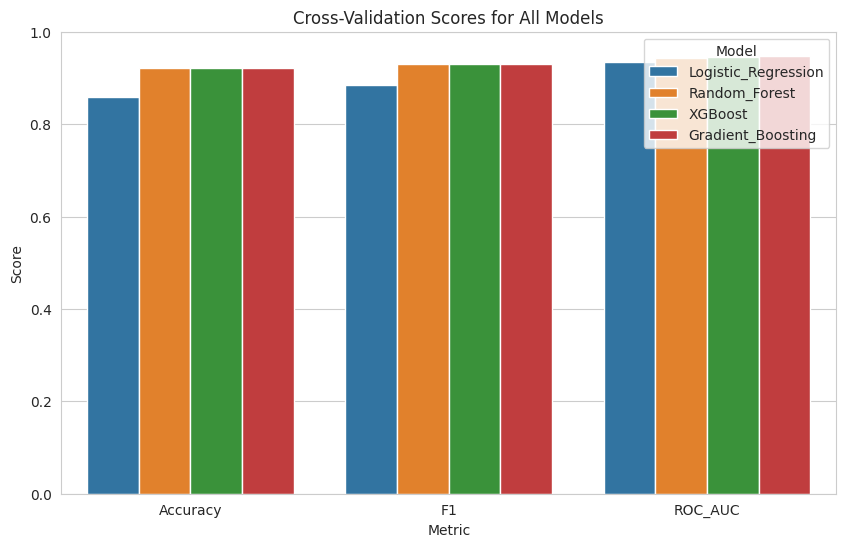

In [45]:
cv_results_melted = cv_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=cv_results_melted)
plt.title("Cross-Validation Scores for All Models")
plt.ylim(0,1)
plt.ylabel("Score")
plt.show()